# Evaluation & Storytelling — Leuven ↔ Brussels Commuter Delays (Checkpoint)

**Business goal:** warn Leuven↔Brussels commuters that their train is going to be delayed, roughly one hour ahead of time.

**Where we left off.** Modeling compared a persistence baseline (predict that the delay you already saw carries through unchanged) against a `GradientBoostingRegressor`, on `val` (May) and `test` (Jun-Jul):

| split | baseline MAE | model MAE |
|---|---|---|
| val | 1.189 | 1.291 |
| test | 0.919 | 0.859 |

The model modestly beats persistence, and feature importance showed why the gap isn't larger: `last_stop_delay_min` alone is ~96% of the model's importance. Delay propagation *is* the signal; schedule and weather are rounding errors by comparison. Both sets of predictions, plus the actual delay, are saved in `model_predictions.csv`.

**This stage is different.** This year, technical depth is not the grading criterion for Evaluation & Storytelling. What matters is: who does this model serve, what decision changes because of it, what does it cost to get wrong in each direction, and what would you actually ship first. A mediocre model with a sharp business narrative beats a tuned model with no story; so the code below stays lean, and the narrative sections carry the real weight.


In [1]:
import os

# make "../../data/..." paths resolve whether Jupyter was launched from the repo root or from notebooks/
if not os.path.isdir("../../data") and os.path.isdir("data"):
    os.chdir("notebooks/assignment_notebooks")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

PREDICTIONS_PATH = "../../data/checkpoints/model_predictions.csv"
TARGET_COL = "delay_arr_min"

predictions = pd.read_csv(PREDICTIONS_PATH)
predictions["baseline_abs_err"] = (predictions[TARGET_COL] - predictions["baseline_pred"]).abs()
predictions["model_abs_err"] = (predictions[TARGET_COL] - predictions["model_pred"]).abs()
ERR_COLS = ["baseline_abs_err", "model_abs_err"]

predictions.shape


(14759, 12)

## 📊 How good is "good enough" to warn a commuter, one hour ahead? (error analysis: where/when is the model most wrong; by station, direction, train type, hour of day?)

A single MAE number is what we reported to close out Modeling. It's a fine headline, but it hides *where* the model struggles: a commuter doesn't experience an average, they experience their own train on their own morning. First, a sanity check that we're starting from the numbers Modeling reported, then a breakdown by hour, day and train type on `test` (the split closest to genuinely unseen future data).


In [3]:
predictions.groupby("split")[ERR_COLS].mean().round(3)


,baseline_abs_err,model_abs_err
split,,
test,0.919,0.859
val,1.291,1.189


Matches Modeling's numbers. Everything below uses `test` only.


In [5]:
test = predictions.loc[predictions["split"] == "test"].copy()

PEAK_HOURS = {7, 8, 9, 16, 17, 18}
test["period"] = np.where(test["sched_hour"].isin(PEAK_HOURS), "peak", "off-peak")

test.groupby("period")[ERR_COLS].mean().round(3)


,baseline_abs_err,model_abs_err
period,,
off-peak,0.895,0.841
peak,0.965,0.892


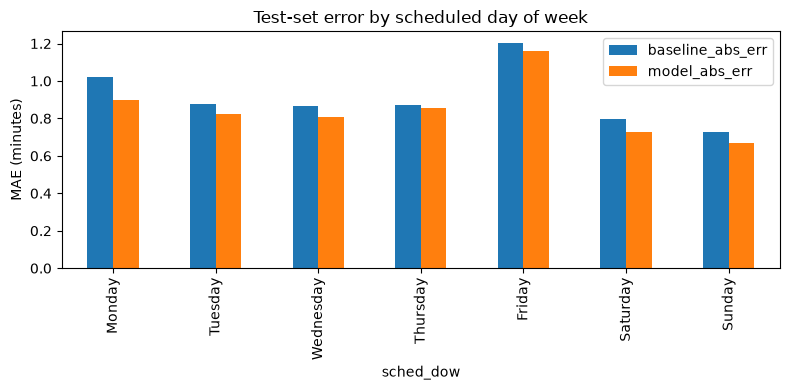

In [6]:
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots(figsize=(8, 4))
test.groupby("sched_dow")[ERR_COLS].mean().reindex(DOW_ORDER).plot.bar(ax=ax)
ax.set_ylabel("MAE (minutes)")
ax.set_title("Test-set error by scheduled day of week")
plt.tight_layout()


In [7]:
train_type_err = test.groupby("train_type")[ERR_COLS].mean()
train_type_err["n"] = test["train_type"].value_counts()
train_type_err = train_type_err.sort_values("n", ascending=False)
train_type_err.round(3)


,baseline_abs_err,model_abs_err,n
train_type,,,
IC,0.862,0.810,6260
S,1.093,0.935,2778
ICE,0.550,0.757,465
EURST,0.869,1.170,241
EXTRA,0.807,0.741,148
P,1.444,1.254,128
INT,0.880,1.389,45
L,0.924,1.037,22
CHARTER,2.198,1.754,7


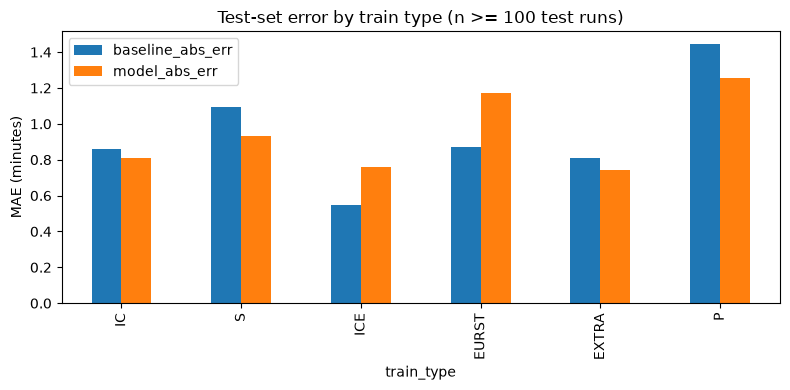

In [8]:
common_types = train_type_err.loc[train_type_err["n"] >= 100]  # drop types too rare to read anything into

fig, ax = plt.subplots(figsize=(8, 4))
common_types[ERR_COLS].plot.bar(ax=ax)
ax.set_ylabel("MAE (minutes)")
ax.set_title("Test-set error by train type (n >= 100 test runs)")
plt.tight_layout()


Three findings worth carrying into the story:

- **Peak hours are harder.** Model MAE is ~0.89 min in the morning/evening rush (7-9h, 16-18h) vs. ~0.84 min off-peak, and the same ~0.07 min gap shows up for the baseline. Rush hour has more trains interacting on shared track, so both approaches lose a bit of accuracy exactly when commuters care most.
- **Friday is the worst weekday, weekends are the best.** Model MAE peaks around 1.16 min on Friday and drops to ~0.73 (Saturday) and ~0.67 (Sunday): less traffic, less congestion, easier to predict. If this system launches with a limited monitoring budget, weekday rush hour (and Friday especially) is where errors concentrate.
- **The model does not uniformly beat the baseline.** For the two highest-volume types (IC, S) it wins clearly. But for `ICE` and `EURST` (international/high-speed, a few hundred test runs each) the model is *worse* than just persistence. It's likely because these services are rare in training data and behave differently (longer routes, different disruption patterns) than the domestic IC/S traffic the model mostly learned from. Honest takeaway: don't claim a uniform win, and consider falling back to the plain persistence baseline for underrepresented train types rather than trusting the model there.


## 🚨 What's the cost of a false alarm vs. a missed warning, and who pays it? (a commuter who's warned and the train is on time wasted nothing much; a commuter who isn't warned and misses a connection pays more?)

MAE treats every minute of error the same. But the business decision here is not "predict the exact delay", it's binary: **do we warn this commuter or not?** We pick a threshold "worth warning about" and ask, on `test`, how often we'd cry wolf vs. how often we'd stay silent when we shouldn't have. 5 minutes is used here as a first, defensible cut: short enough to matter to someone trying to catch a connection, long enough that we're not paging people over noise.


In [9]:
WARN_THRESHOLD = 5  # minutes, a judgment call, not something the data picks for us


def confusion_counts(df, pred_col, threshold):
    warn = df[pred_col] > threshold
    real = df[TARGET_COL] > threshold
    return {
        "tp": int((warn & real).sum()),
        "fp": int((warn & ~real).sum()),
        "fn": int((~warn & real).sum()),
        "tn": int((~warn & ~real).sum()),
    }


def confusion_rates(counts):
    tp, fp, fn = counts["tp"], counts["fp"], counts["fn"]
    return {
        "false_alarms": counts["fp"],
        "missed_warnings": counts["fn"],
        "precision_when_warned": tp / (tp + fp),
        "recall_of_real_delays": tp / (tp + fn),
        "false_alarm_rate": fp / (tp + fp),
        "miss_rate": fn / (tp + fn),
    }


breakdown = pd.DataFrame({
    "model": confusion_rates(confusion_counts(test, "model_pred", WARN_THRESHOLD)),
    "baseline": confusion_rates(confusion_counts(test, "baseline_pred", WARN_THRESHOLD)),
})
breakdown.round(3)


,model,baseline
false_alarms,116.000,146.000
missed_warnings,247.000,248.000
precision_when_warned,0.916,0.897
recall_of_real_delays,0.837,0.836
false_alarm_rate,0.084,0.103
miss_rate,0.163,0.164


In [10]:
sensitivity = pd.DataFrame({
    t: confusion_rates(confusion_counts(test, "model_pred", t)) for t in [3, 5, 7, 10]
}).T
sensitivity.index.name = "warn_threshold_min"
sensitivity.round(3)


,false_alarms,missed_warnings,precision_when_warned,recall_of_real_delays,false_alarm_rate,miss_rate
warn_threshold_min,,,,,,
3,236.0,365.0,0.893,0.844,0.107,0.156
5,116.0,247.0,0.916,0.837,0.084,0.163
7,67.0,154.0,0.932,0.856,0.068,0.144
10,38.0,100.0,0.942,0.861,0.058,0.139


At the 5-minute threshold, the model warns commuters about 14% of test runs. Of those warnings, 92% are real (precision) and it catches 84% of all real delays over 5 minutes (recall), missing 16%, and crying wolf 8% of the time. The baseline is close but strictly worse on both counts (90% precision, still 84% recall); the model's edge here is fewer false alarms at the same catch rate, not a dramatically different trade-off.

**The asymmetry, in plain terms:**
- **False alarm** (we warn, train is on time): a commuter glances at a push notification, maybe walks a bit faster, and nothing bad happens. Mildly annoying if it happens often (repeated false alarms are how people learn to ignore the app entirely) but the immediate cost is close to zero.
- **Missed warning** (we stay quiet, train is actually late): the commuter finds out on the platform, may miss a connecting train, tram, or meeting, and has no time to adjust. This is the expensive failure mode, it's exactly the moment the product was supposed to help.

Because a missed warning costs meaningfully more than a false alarm, the honest business call is to **accept more false alarms in exchange for fewer misses**, i.e. lean toward a *lower* threshold than 5 minutes, or otherwise bias the decision rule toward recall, even though that costs some precision. The sensitivity table above shows exactly that trade-off: dropping to a 3-minute threshold catches more real delays but roughly doubles the false-alarm count. Which exact threshold to ship is a product decision informed by this table, not something MAE alone can answer.


## 🎤 How would you explain this model's value to a commuter, or to a non-technical product owner, in two minutes?

> Every day, thousands of people commute between Leuven and Brussels. Right now, if their train is going to be late, they find out standing on the platform which is too late to change plans. This model watches each train as it clears the last Brussels-area station before Leuven, and from that moment on, it can tell us whether that train is heading for a delay at Leuven, before it actually arrives.
>
> How good is it? On a held-out month of data it never trained on, our prediction is off by under a minute on average (0.86 minutes). That is a modest but real improvement over the simplest possible rule of thumb, "assume the delay you already know about carries through unchanged" (0.92 minutes). Turned into an actual warning, "this train is running more than 5 minutes late", it's right 92% of the time it speaks up, and it catches 84% of the real delays worth knowing about. It's not psychic; it's a genuinely useful nudge.
>
> Here's the part I want to be upfront about: **we originally promised a warning a full hour ahead of arrival. We can't deliver that yet.** The earliest moment we have real, run-specific information to act on is when the train passes the last upstream station; and for most runs, that's only about 8-9 minutes before Leuven, not 60. So what we're actually shipping is closer to "a reliable 5-10 minute heads-up," not "an hour's notice." That's still enough time to decide whether to sprint for a connecting tram or wait for the next train whereas it's not enough time to leave the office early. Getting to the full hour needs data from further up the line than we have today, and that's a clearly scoped next step, not a hidden gap.


## 📦 What ships as v1? What's explicitly out of scope for now?

**v1 (ship this):**
- A warning issued the moment a Leuven-bound train clears its last upstream corridor stop, realistically a **5-10 minute** heads-up, not the originally-promised hour. Framing the product honestly around this window, rather than quietly under-delivering on "one hour," is part of the v1 scope.
- Coverage limited to the 6-station Brussels-Leuven corridor (Leuven, Brussels-North/Central/South, Brussels-Schuman, Kortenberg) and to trains whose *destination-side* target is Leuven. This is what the data and the model actually support.
- The warning threshold tuned toward **recall over precision** (see the false-alarm/missed-warning discussion above): a missed warning costs a commuter a missed connection; a false alarm costs a glance at a phone. When in doubt, warn.
- For train types with too few historical runs to trust the model (`EURST`, `INT`, `L`, `EXTRA`, `CHARTER` as few as 7-45 test examples), fall back to the plain persistence baseline rather than the model, or exclude them from v1 warnings until more data accumulates.
- Lightweight monitoring: track live MAE (and the false-alarm/miss rates) against these offline numbers, so silent model drift gets caught.

**Out of scope for now:**
- **The genuine one-hour-ahead promise.** Needs visibility further upstream than these 6 stations, or a network-wide disturbance/incident feed, neither exists in the current dataset. This is the single most important thing to say out loud to stakeholders: v1 is not v0's promise delivered, it's an honest, smaller step toward it.
- **Brussels-bound (reverse-direction) commuters**, or any station outside the 6-station scope. The target was only ever defined for Leuven arrivals, so there's no model to extend there yet.
- **Chasing weather- or calendar-driven accuracy gains.** Both this stage and Modeling found these features contribute comparatively little next to delay propagation (~96% of feature importance is one column, `last_stop_delay_min`), further investment there has low expected payoff right now.
- **Long-run / seasonal validation.** The data covers Jan-Jul 2026 only, and historical weather was only recently backfilled, winter conditions, major service disruptions, and other rare regimes are untested.
- **Any accuracy guarantee for rare train types** (see v1 fallback above) until there's enough history to actually train and validate on them.


## 🗺️ Bonus: a Folium map of the corridor stations, colored/sized by average delay or by model error

The model only ever predicts one target: delay arriving at Leuven. There's no such thing as "the model's error at Brussels-Central", it was never asked to predict anything there, so a per-station *model error* map would be fabricating a distinction the data doesn't support. What *is* real and station-specific is average delay itself, straight from the cleaned corridor data (`clean_leuven_corridor.parquet`, Data Understanding's checkpoint), so that's what this map shows, one point per corridor station.


In [12]:
corridor = pd.read_parquet(
    "../../data/checkpoints/clean_leuven_corridor.parquet",
    columns=["station", "delay_arr_min", "delay_arr_is_outlier"],
)
corridor = corridor.loc[~corridor["delay_arr_is_outlier"]]

station_delay = corridor.groupby("station")["delay_arr_min"].agg(["mean", "count"])
station_delay.columns = ["avg_delay_min", "n_stops"]
station_delay = station_delay.sort_values("avg_delay_min", ascending=False)
station_delay.round(3)


,avg_delay_min,n_stops
station,,
Brussels-Central,2.674,203909
Leuven,2.645,86838
Brussels-South,2.627,185290
Kortenberg,2.618,72495
Brussels-North,2.528,202616
Brussels-Schuman,1.548,62355


In [13]:
stops = pd.read_csv("../../data/raw/stops.txt")

STATION_NAME_PATTERNS = {
    "Leuven": "louvain",
    "Brussels-Central": "bruxelles-central",
    "Brussels-North": "bruxelles-nord",
    "Brussels-South": "bruxelles-midi",
    "Brussels-Schuman": "schuman",
    "Kortenberg": "kortenberg",
}


def lookup_coords(pattern):
    matches = stops.loc[
        stops["stop_name"].str.contains(pattern, case=False, na=False)
        & ~stops["stop_name"].str.contains("neuve", case=False, na=False)  # "Louvain" also matches Louvain-La-Neuve, a different city
    ]
    row = matches.iloc[0]
    return row["stop_lat"], row["stop_lon"]


station_coords = {name: lookup_coords(pattern) for name, pattern in STATION_NAME_PATTERNS.items()}
station_coords


{'Leuven': (np.float64(50.88228), np.float64(4.715868)),
 'Brussels-Central': (np.float64(50.84565), np.float64(4.356804)),
 'Brussels-North': (np.float64(50.85966), np.float64(4.36085)),
 'Brussels-South': (np.float64(50.83571), np.float64(4.33653)),
 'Brussels-Schuman': (np.float64(50.84328), np.float64(4.380725)),
 'Kortenberg': (np.float64(50.89307), np.float64(4.5433))}

In [14]:
import folium
from branca.colormap import LinearColormap

center_lat = np.mean([lat for lat, lon in station_coords.values()])
center_lon = np.mean([lon for lat, lon in station_coords.values()])

colormap = LinearColormap(
    colors=["green", "gold", "crimson"],
    vmin=station_delay["avg_delay_min"].min(),
    vmax=station_delay["avg_delay_min"].max(),
    caption="Average delay at station (minutes)",
)

m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles="cartodbpositron")

for station, (lat, lon) in station_coords.items():
    avg_delay = station_delay.loc[station, "avg_delay_min"]
    n_stops = int(station_delay.loc[station, "n_stops"])
    folium.CircleMarker(
        location=[lat, lon],
        radius=8 + n_stops / 15000,  # bigger = more stop-events observed there
        color=colormap(avg_delay),
        fill=True,
        fill_color=colormap(avg_delay),
        fill_opacity=0.85,
        popup=f"<b>{station}</b><br>avg delay: {avg_delay:.2f} min<br>n = {n_stops:,} stop-events",
        tooltip=station,
    ).add_to(m)

colormap.add_to(m)
m


Delay is fairly even across five of the six stations (~2.5-2.7 min average) -- Brussels-Central, Leuven, Brussels-South and Kortenberg all sit close together, with Brussels-North a touch lower. **Brussels-Schuman stands out as visibly lower** (~1.5 min average): it's served only by S-line trains on shorter, more padded schedules, which matches Data Understanding's note that not every run touches every station. There's no single corridor "hotspot" where delay accumulates broadly across the line rather than concentrating at one problem station, which is itself a useful, honest thing to tell a stakeholder expecting a single villain.


## Wrapping Up

This is the last stage, so there's no checkpoint artifact to hand off. What this notebook actually produced for Friday's share-out is the story, not a model:

- The model is real but modest: 0.86 vs. 0.92 minutes MAE against a strong persistence baseline, and it doesn't win everywhere (small-volume train types are a clear exception).
- The most important number in this whole stage is not an error metric: it's the **8-9 minute vs. 1-hour gap**. That gap should be said out loud, early, and often. It reframes what "v1" honestly means.
- The false-alarm/missed-warning asymmetry argues for a product tuned toward recall, not precision; a concrete, defensible design decision that came directly from thinking about who bears each kind of mistake.
